Saving Renewable_Energy_Data.csv to Renewable_Energy_Data.csv
First 5 Rows
  Region Energy_Source  Temperature_C  Wind_Speed_m_s  Solar_Radiation_kWh_m2  \
0  North         Hydro      13.820937       14.362462                8.834648   
1  North         Solar      36.972782       19.110474                4.483191   
2   East         Hydro      33.972875        0.364652                5.104325   
3  South         Solar      -2.965160        3.915560                6.265925   
4  North          Wind      -3.813486        0.151257                9.263826   

   Rainfall_mm  Season  Efficiency_Ratio  Lagged_Production_MWh  \
0     3.350827  Winter        125.449109            1419.514155   
1    48.767157  Winter         16.325089            4769.329958   
2    40.848695  Winter        155.637061            1005.077719   
3    42.627371  Spring        675.516566            6294.250931   
4    46.898262  Spring        626.048277            5550.263638   

   Combined_Weather_Index Energy_Cl

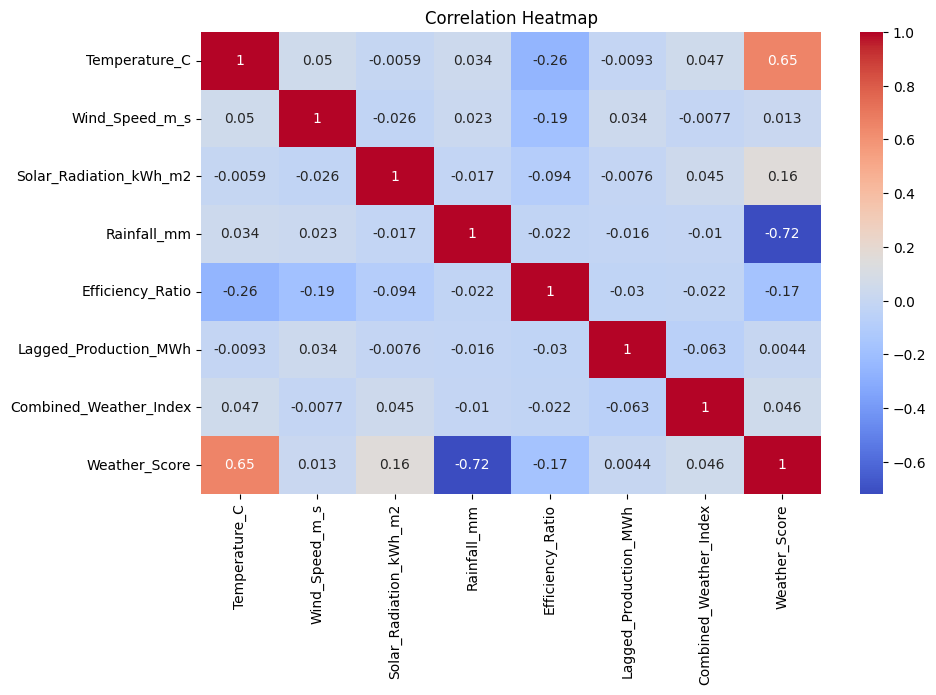

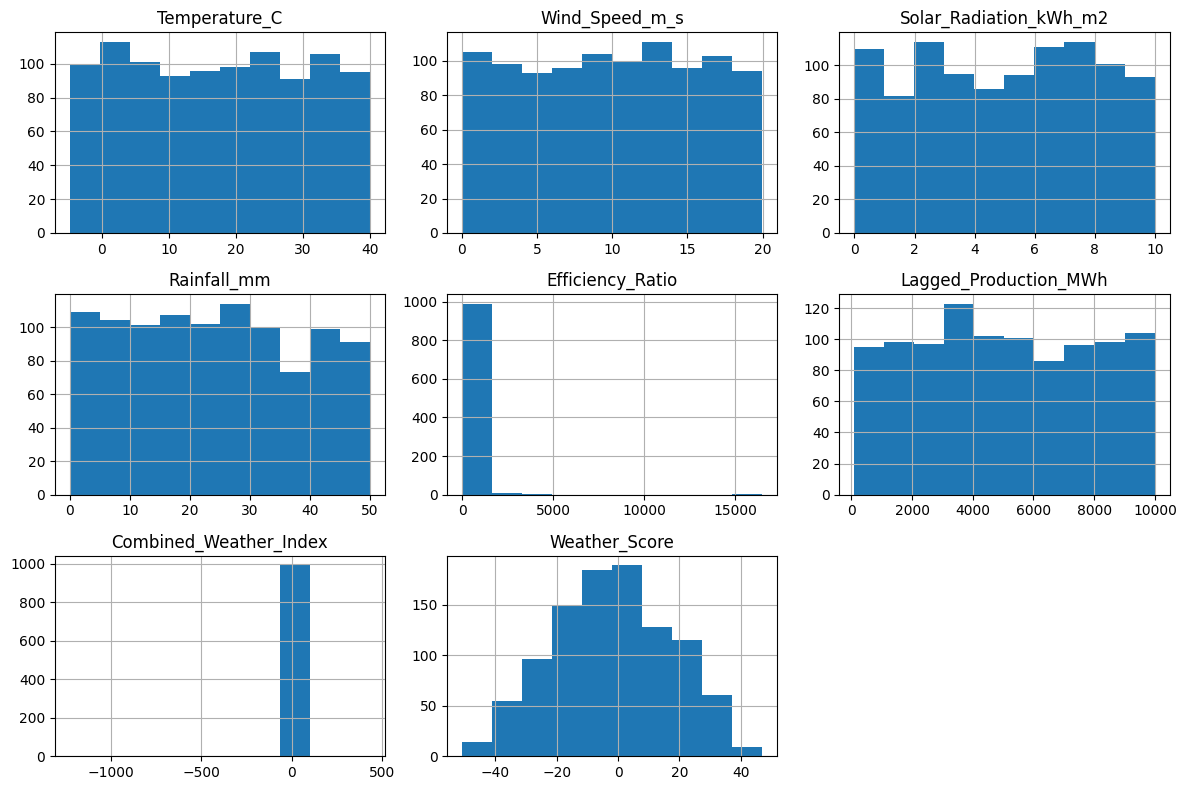

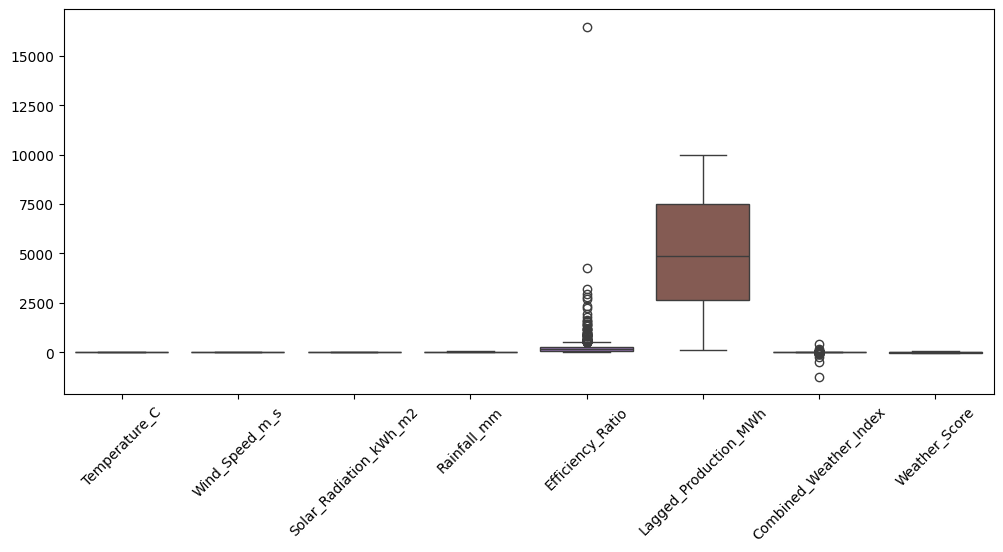

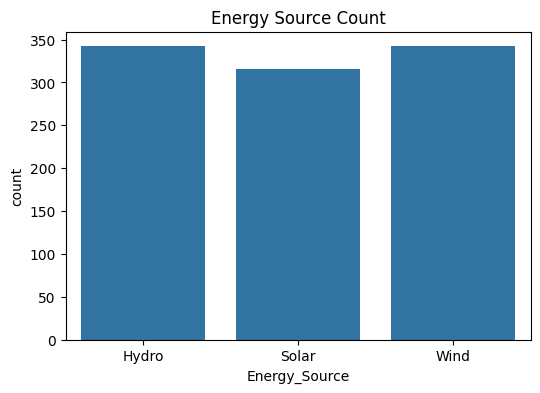

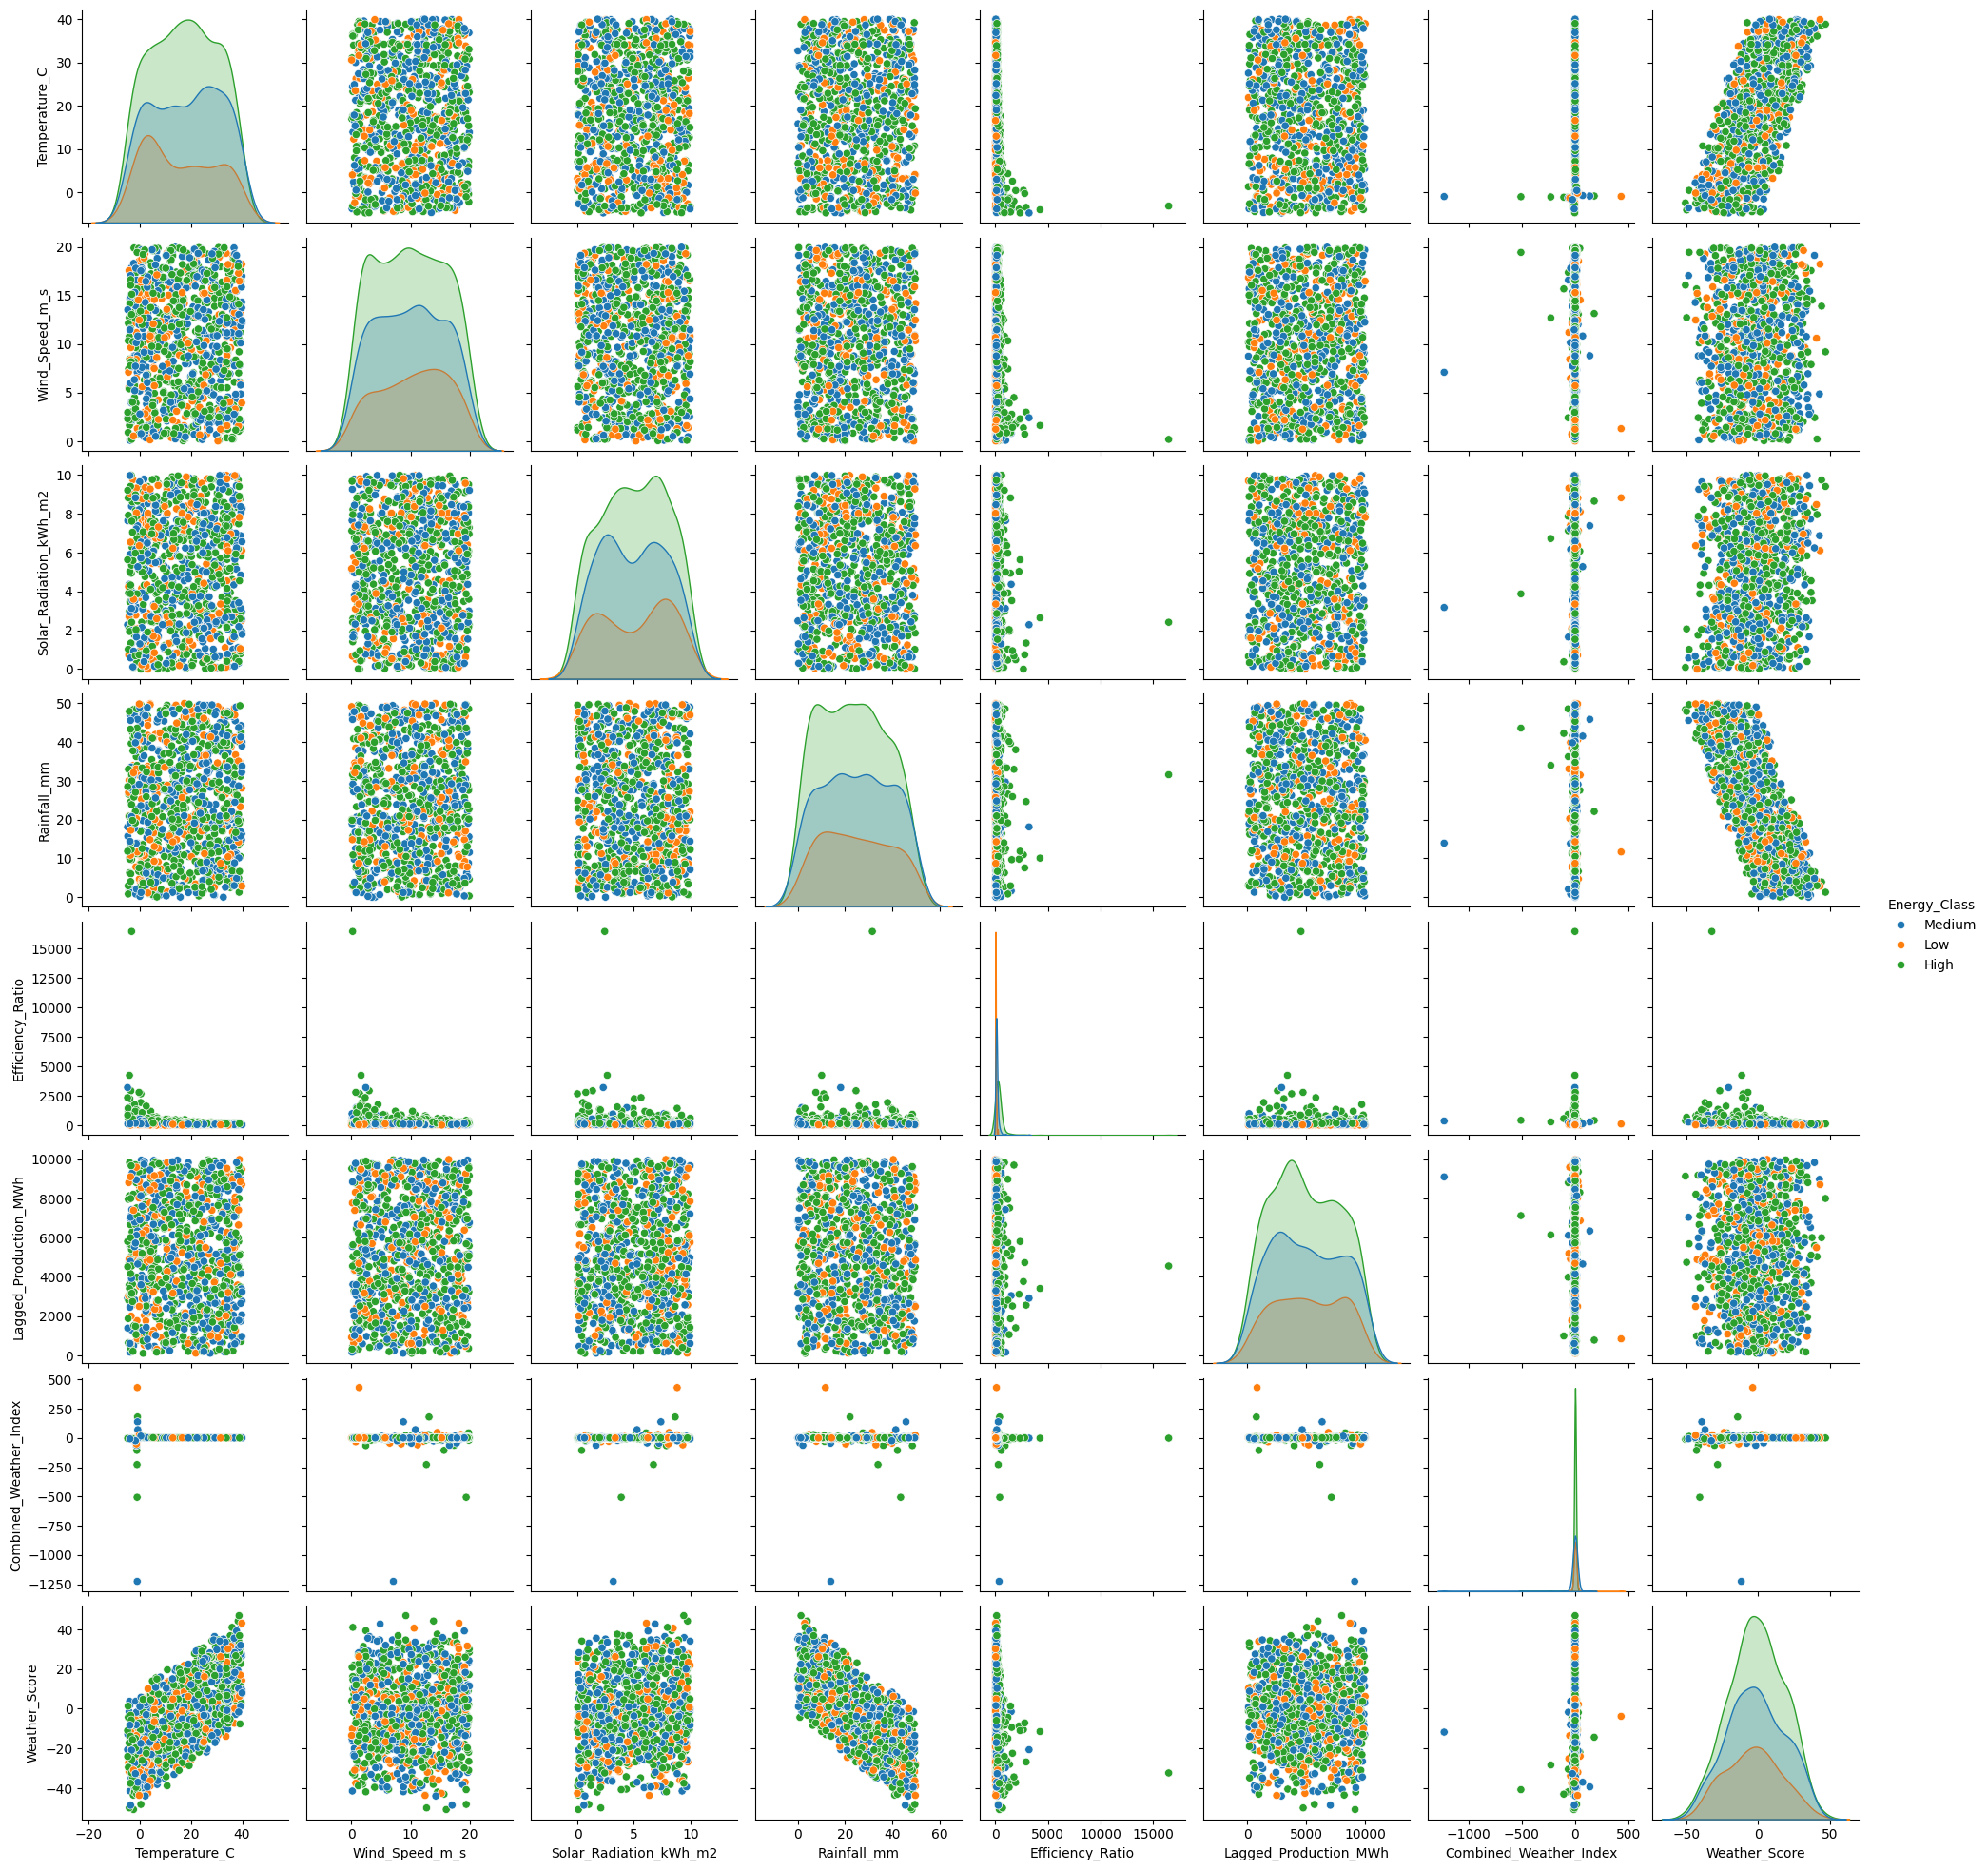


Categorical Columns Encoded

Scaled Dataset
   Region  Energy_Source  Temperature_C  Wind_Speed_m_s  \
0       1              0      -0.274016        0.761406   
1       1              1       1.494207        1.587239   
2       0              0       1.265089       -1.673268   
3       2              1      -1.556055       -1.055650   
4       1              2      -1.620846       -1.710384   

   Solar_Radiation_kWh_m2  Rainfall_mm  Season  Efficiency_Ratio  \
0                1.321096    -1.459326       3         -0.183511   
1               -0.182743     1.723699       3         -0.364414   
2                0.031918     1.168730       3         -0.133466   
3                0.433360     1.293389       1          0.728380   
4                1.469417     1.592716       1          0.646372   

   Lagged_Production_MWh  Combined_Weather_Index  Energy_Class  Weather_Score  
0              -1.269659                0.049992             2       1.092478  
1              -0.090058       

In [ ]:
# GTU Skills4Future Internship
# Day-4 Task
# Iris Dataset Analysis

# Import Libraries
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

# Upload Dataset
uploaded = files.upload()

# Read Dataset
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# ==========================
# Dataset Information
# ==========================

print("First 5 Rows")
print(df.head())

print("\nShape of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
df.info()

print("\nSummary Statistics")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

# ==========================
# Handle Missing Values
# ==========================

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col].fillna(df[col].mean(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# ==========================
# Dataset Analysis
# ==========================

# sepal_length -> Length of Sepal
# sepal_width -> Width of Sepal
# petal_length -> Length of Petal
# petal_width -> Width of Petal
# species -> Flower Species

# Petal length and petal width are strongly related.
# Sepal length has a moderate relationship with petal length.
# Species can be identified using petal measurements.

# ==========================
# Feature Engineering
# ==========================

df["Flower_Size"] = (
    df["sepal_length"] +
    df["petal_length"]
)

print("\nFlower_Size Feature Added")

# ==========================
# Correlation Heatmap
# ==========================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ==========================
# Histograms
# ==========================

numeric_df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

# ==========================
# Boxplot
# ==========================

plt.figure(figsize=(8,5))
sns.boxplot(data=numeric_df)
plt.xticks(rotation=45)
plt.show()

# ==========================
# Countplot
# ==========================

plt.figure(figsize=(6,4))
sns.countplot(x="species", data=df)
plt.title("Species Count")
plt.show()

# ==========================
# Pairplot
# ==========================

sns.pairplot(df, hue="species")
plt.show()

# ==========================
# Label Encoding
# ==========================

encoder = LabelEncoder()

df["species"] = encoder.fit_transform(df["species"])

print("\nSpecies Encoded")

# ==========================
# Standard Scaling
# ==========================

scaler = StandardScaler()

numerical_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "Flower_Size"
]

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print("\nScaled Dataset")
print(df.head())

# ==========================
# Final Insights
# ==========================

print("\n================ FINAL INSIGHTS ================")

print("1. Dataset contains 150 records and 5 original columns.")
print("2. Missing values were checked and handled.")
print("3. Petal length and petal width have a strong positive correlation.")
print("4. Heatmap shows relationships among numerical features.")
print("5. Histograms display the distribution of each feature.")
print("6. Boxplots help identify outliers.")
print("7. Countplot shows the number of flowers in each species.")
print("8. Pairplot clearly separates the three Iris species.")
print("9. Flower_Size feature was created using feature engineering.")
print("10. Species column was converted into numerical values using Label Encoding.")
print("11. Numerical features were standardized using StandardScaler.")
print("12. Dataset is cleaned and ready for machine learning.")